In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)

# Read the CSV
df = pd.read_csv("datasetM.csv")   # adjust path if needed
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1936,M16795,Medium,NaN,307.9,2754,82.0959022,42.0,0,0,0,0,0,0
1,6495,L53674,Low,300.6,309.7,1617,31.68412504,185.0,0,0,0,0,0,0
2,1721,L48900,Low,NaN,307.7,1459,45.13900611,89.0,0,0,0,0,0,0
3,9121,L56300,L,297.4,308.4,1525,39.89688289,62.0,0,0,0,0,0,0
4,361,M15220,M,297.5,308.3,1521,36.93240173,74.0,0,0,0,0,0,0


In [2]:
df.info()              # column names, dtypes, non-null counts
df.describe().T        # summary stats for numeric columns
print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Duplicates:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      12000 non-null  int64  
 1   Product ID               12000 non-null  object 
 2   Type                     12000 non-null  object 
 3   Air temperature [K]      10510 non-null  object 
 4   Process temperature [K]  10480 non-null  object 
 5   Rotational speed [rpm]   10463 non-null  object 
 6   Torque [Nm]              10483 non-null  object 
 7   Tool wear [min]          10482 non-null  float64
 8   Machine failure          12000 non-null  int64  
 9   TWF                      12000 non-null  int64  
 10  HDF                      12000 non-null  int64  
 11  PWF                      12000 non-null  object 
 12  OSF                      12000 non-null  object 
 13  RNF                      12000 non-null  int64  
dtypes: float64(1), int64(5

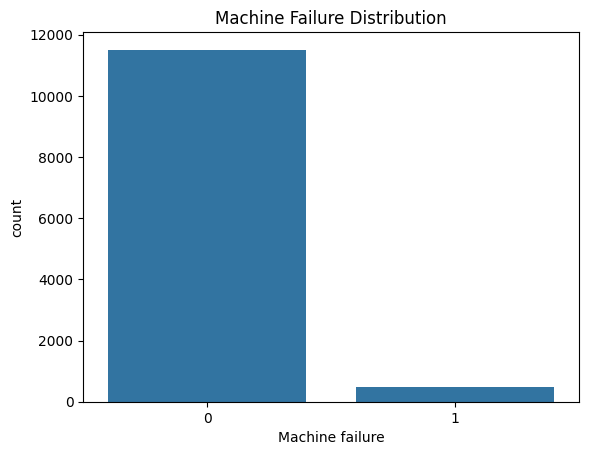

In [3]:
df["Machine failure"].value_counts(normalize=True)*100
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.show()


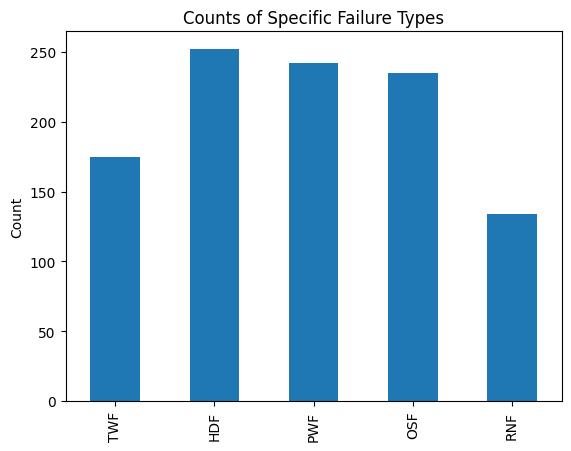

In [6]:
cause_cols = ["TWF","HDF","PWF","OSF","RNF"]

# Convert PWF and OSF to numeric, coercing errors, and fill NaN with 0
df['PWF'] = pd.to_numeric(df['PWF'], errors='coerce').fillna(0).astype(int)
df['OSF'] = pd.to_numeric(df['OSF'], errors='coerce').fillna(0).astype(int)

df[cause_cols].sum().plot(kind="bar")
plt.title("Counts of Specific Failure Types")
plt.ylabel("Count")
plt.show()

In [5]:
print(df['PWF'].unique())
print(df['OSF'].unique())

['0' '1' 'fgbd']
['0' '1' 'rsth' 'srthg' 'srth']


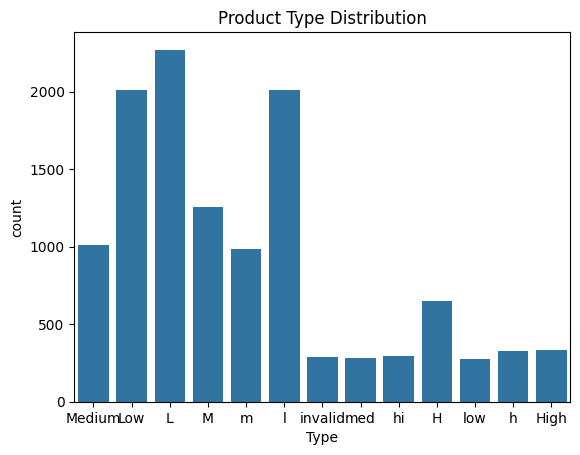

In [7]:
sns.countplot(x="Type", data=df)
plt.title("Product Type Distribution")
plt.show()


<Axes: xlabel='Type', ylabel='count'>

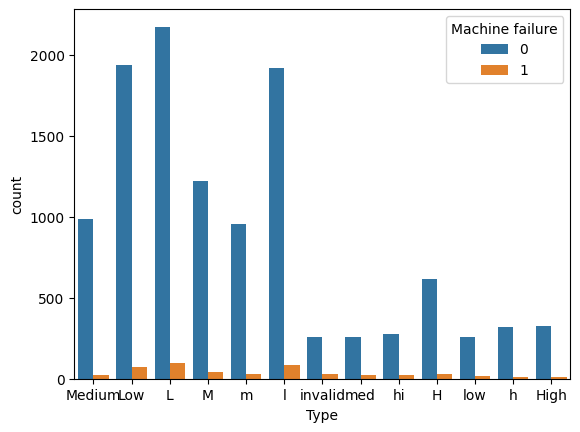

In [8]:
sns.countplot(x="Type", hue="Machine failure", data=df)


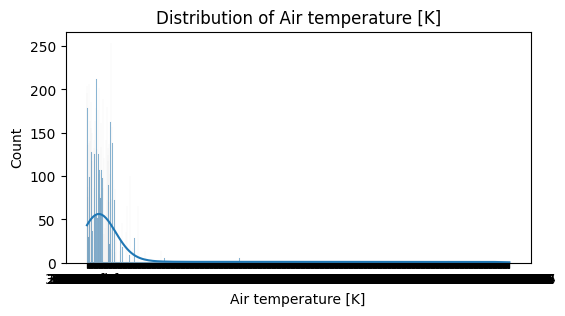

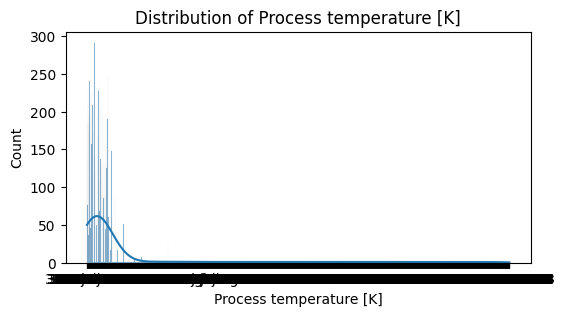

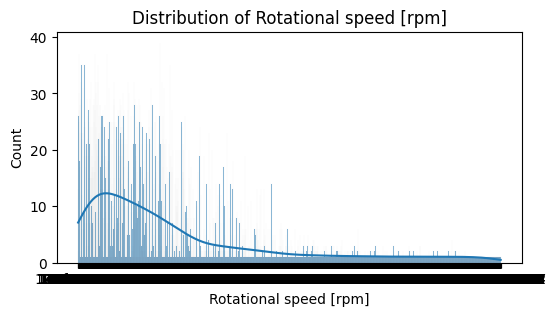

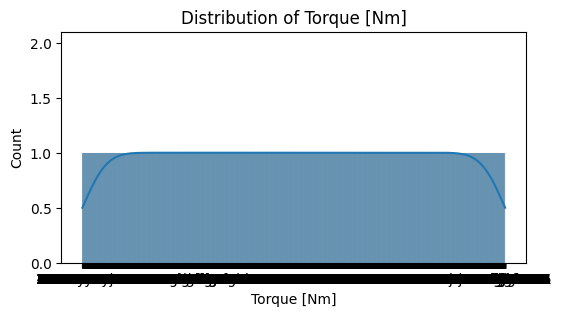

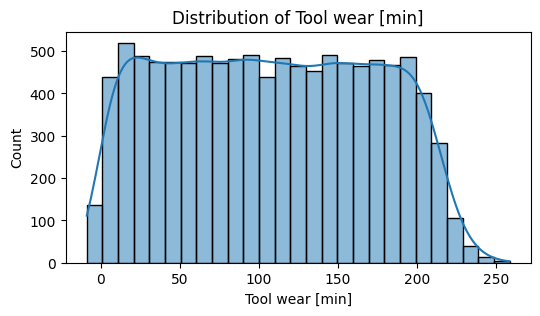

In [9]:
num_cols = ["Air temperature [K]","Process temperature [K]",
            "Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


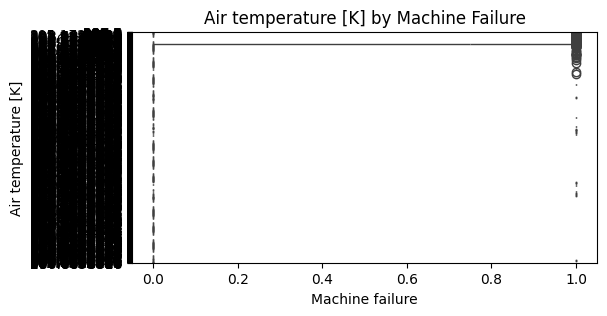

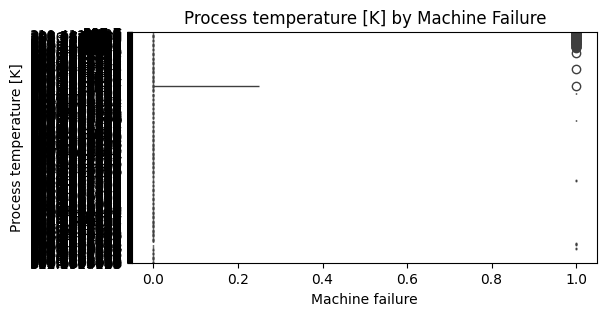

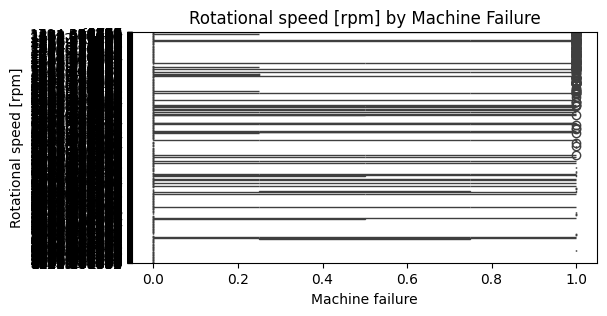

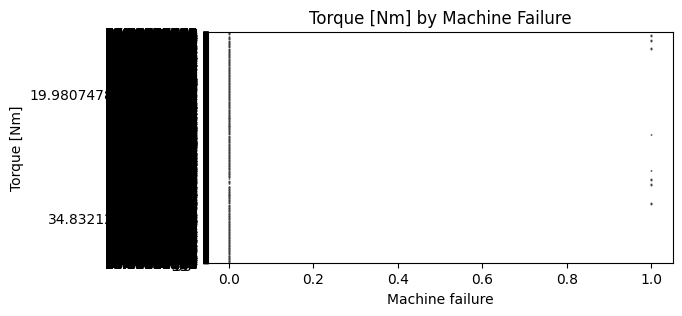

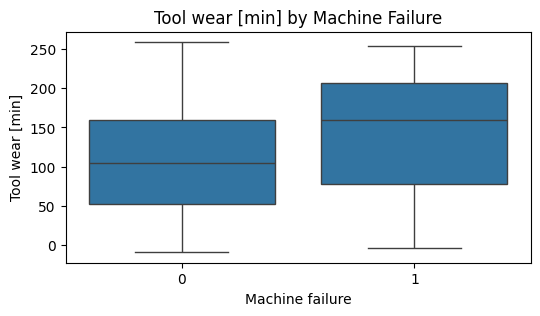

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x="Machine failure", y=col, data=df)
    plt.title(f"{col} by Machine Failure")
    plt.show()


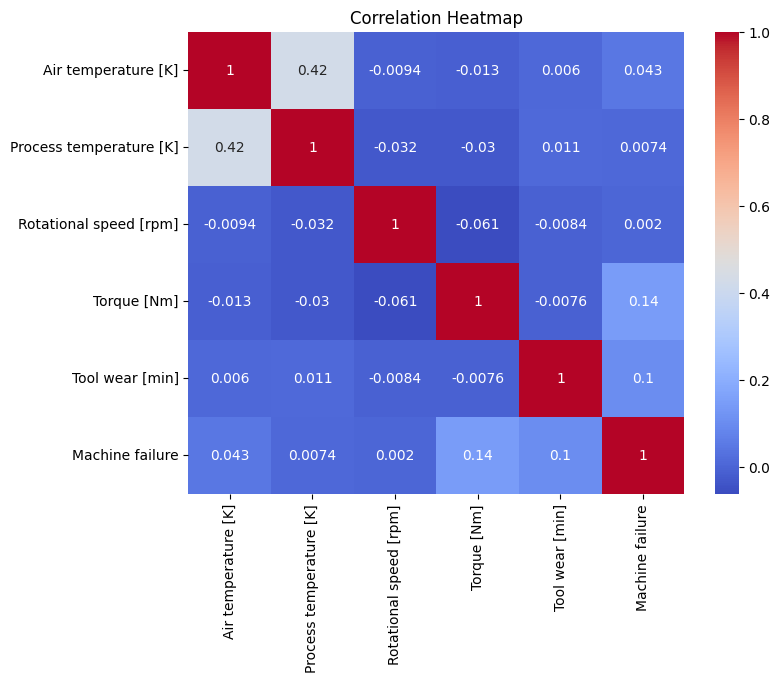

In [12]:
num_cols = ["Air temperature [K]","Process temperature [K]",
            "Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]

# Convert numeric columns to numeric, coercing errors
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

corr = df[num_cols + ["Machine failure"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

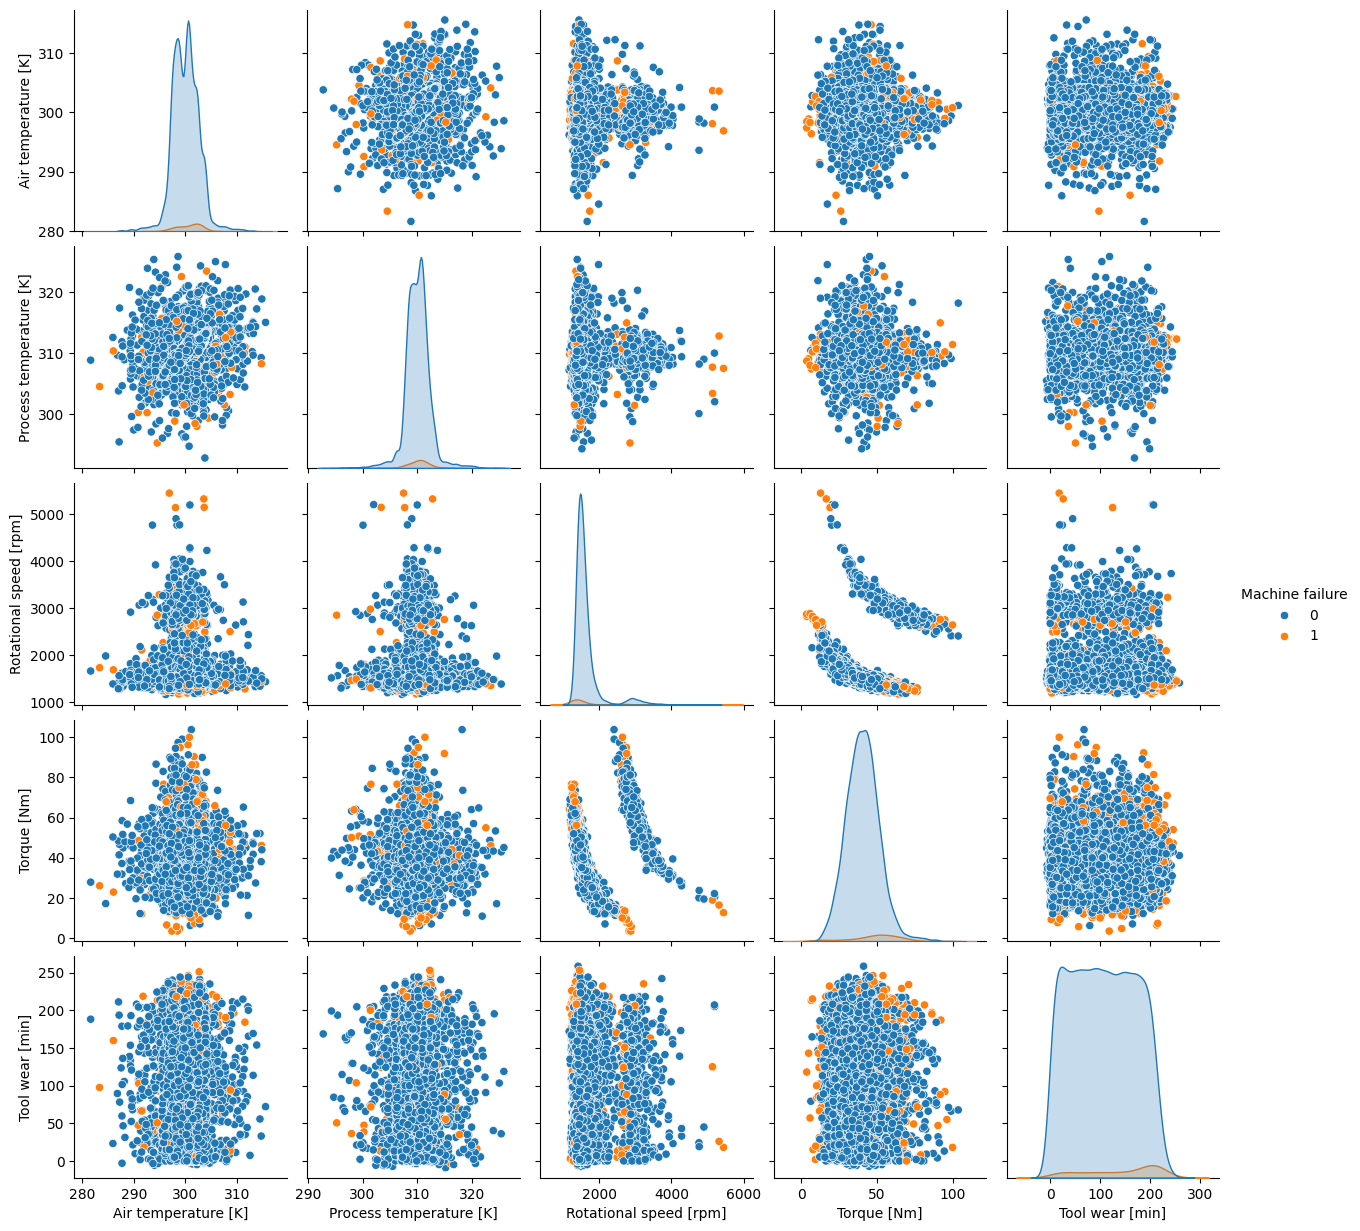

In [13]:
sns.pairplot(df[num_cols + ["Machine failure"]],
             hue="Machine failure", diag_kind="kde")
plt.show()

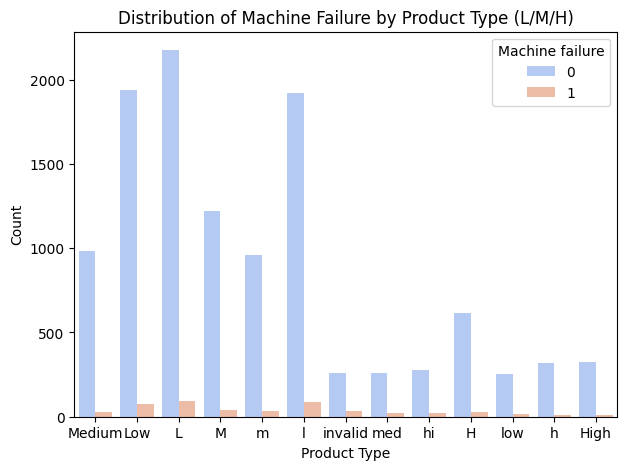

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x='Type', hue='Machine failure', data=df, palette='coolwarm')
plt.title("Distribution of Machine Failure by Product Type (L/M/H)")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.show()


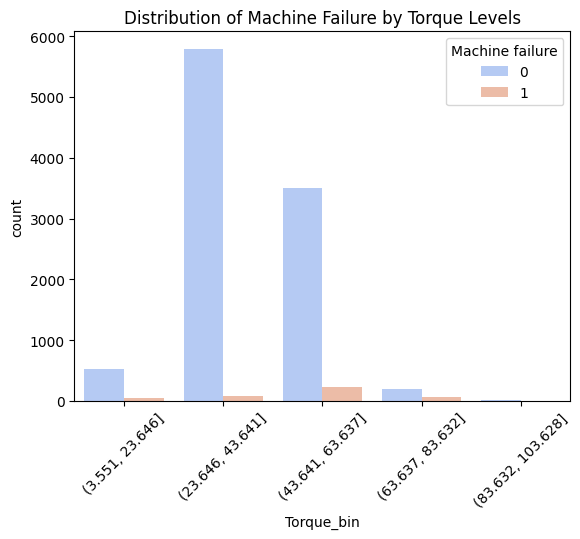

In [16]:
df['Torque_bin'] = pd.cut(df['Torque [Nm]'], bins=5)
sns.countplot(data=df, x='Torque_bin', hue='Machine failure', palette='coolwarm')
plt.title("Distribution of Machine Failure by Torque Levels")
plt.xticks(rotation=45)
plt.show()


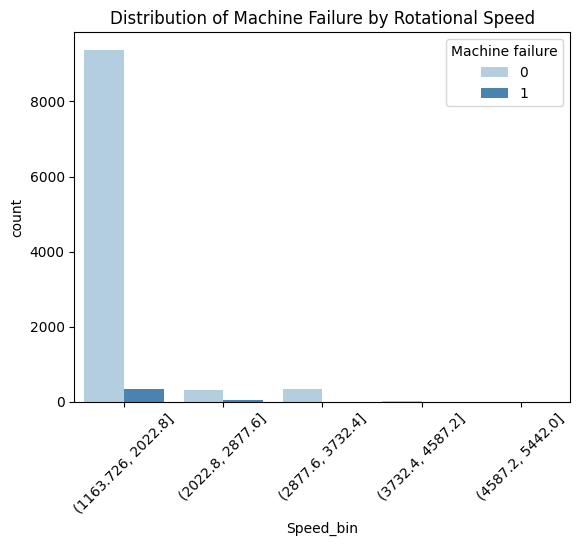

In [17]:
df['Speed_bin'] = pd.cut(df['Rotational speed [rpm]'], bins=5)
sns.countplot(data=df, x='Speed_bin', hue='Machine failure', palette='Blues')
plt.title("Distribution of Machine Failure by Rotational Speed")
plt.xticks(rotation=45)
plt.show()


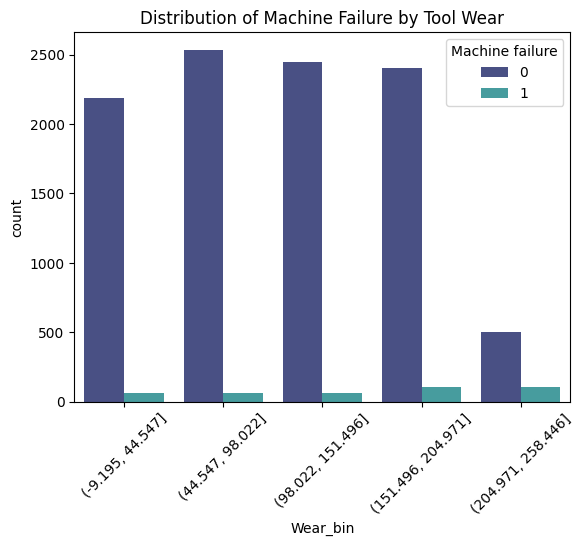

In [18]:
df['Wear_bin'] = pd.cut(df['Tool wear [min]'], bins=5)
sns.countplot(data=df, x='Wear_bin', hue='Machine failure', palette='mako')
plt.title("Distribution of Machine Failure by Tool Wear")
plt.xticks(rotation=45)
plt.show()


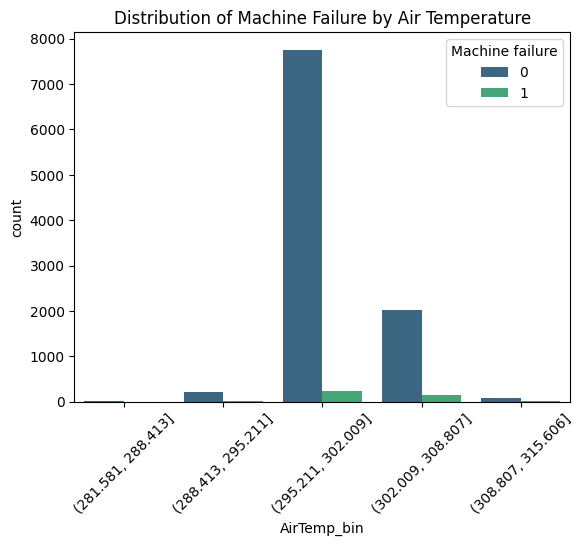

In [19]:
df['AirTemp_bin'] = pd.cut(df['Air temperature [K]'], bins=5)
sns.countplot(data=df, x='AirTemp_bin', hue='Machine failure', palette='viridis')
plt.title("Distribution of Machine Failure by Air Temperature")
plt.xticks(rotation=45)
plt.show()


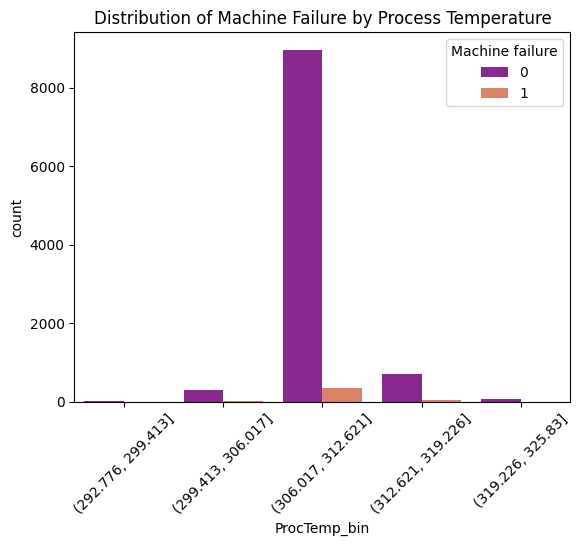

In [20]:
df['ProcTemp_bin'] = pd.cut(df['Process temperature [K]'], bins=5)
sns.countplot(data=df, x='ProcTemp_bin', hue='Machine failure', palette='plasma')
plt.title("Distribution of Machine Failure by Process Temperature")
plt.xticks(rotation=45)
plt.show()


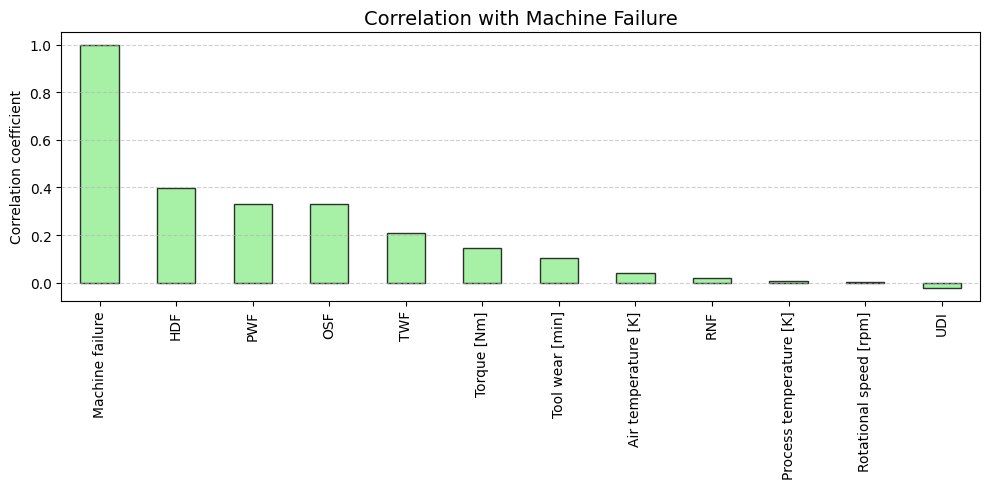

In [21]:

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns


corr_with_fail = df[numeric_cols].corr()['Machine failure'].sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,5))
corr_with_fail.plot(kind='bar', color='lightgreen', edgecolor='black', alpha=0.8)
plt.title("Correlation with Machine Failure", fontsize=14)
plt.ylabel("Correlation coefficient")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Process Temperature [K]')

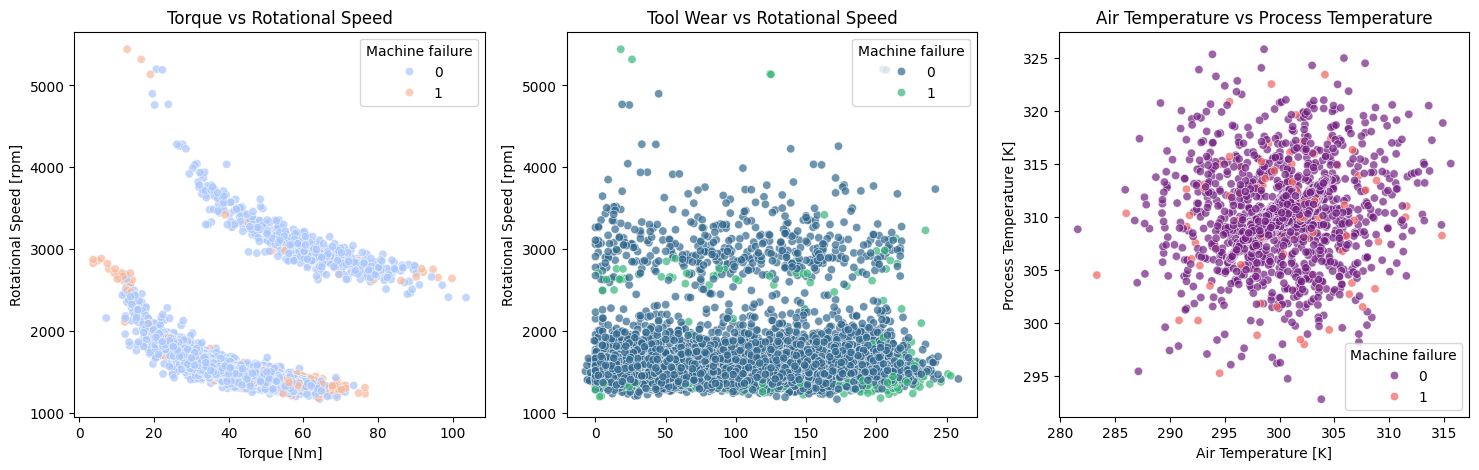

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

# --- 1. Torque vs Rotational Speed ---
plt.subplot(1, 3, 1)
sns.scatterplot(x='Torque [Nm]', y='Rotational speed [rpm]', hue='Machine failure', data=df, palette='coolwarm', alpha=0.7)
plt.title('Torque vs Rotational Speed')
plt.xlabel('Torque [Nm]')
plt.ylabel('Rotational Speed [rpm]')

# --- 2. Tool Wear vs Rotational Speed ---
plt.subplot(1, 3, 2)
sns.scatterplot(x='Tool wear [min]', y='Rotational speed [rpm]', hue='Machine failure', data=df, palette='viridis', alpha=0.7)
plt.title('Tool Wear vs Rotational Speed')
plt.xlabel('Tool Wear [min]')
plt.ylabel('Rotational Speed [rpm]')

# --- 3. Air Temperature vs Process Temperature ---
plt.subplot(1, 3, 3)
sns.scatterplot(x='Air temperature [K]', y='Process temperature [K]', hue='Machine failure', data=df, palette='magma', alpha=0.7)
plt.title('Air Temperature vs Process Temperature')
plt.xlabel('Air Temperature [K]')
plt.ylabel('Process Temperature [K]')


